Data komentar (query + text)

↓
Preprocessing teks (cleaning, stopword, dll)

↓
Pelabelan sentimen (Positif / Negatif / Netral)  ← perlu dilakukan manual/semi-otomatis

↓
Training model deep learning (LSTM / IndoBERT)

↓
Evaluasi akurasi training & testing set

## #1 Preprocessing Data
Memulai pemrosesan data untuk youtube_dataset.json


In [136]:
import pandas as pd
import numpy as np
import json
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import emoji


In [51]:
# Load data
with open("youtube_dataset.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Jadikan DataFrame dan ambil hanya kolom query + text
df = pd.DataFrame(data)[["query", "text"]]

In [4]:
# cek apakah ada baris kosong
print(df[df["text"].str.strip() == ""])

df.isnull().sum()

Empty DataFrame
Columns: [query, text]
Index: []


query    0
text     0
dtype: int64

In [52]:
# 
df = df.reset_index(drop=True)

print(f"Total data: {len(df)}")
print(df.head())

Total data: 82509
                      query                                               text
0  korban menjadi tersangka  Sudah jelas ya. Penegak hukum,polisi,Jaksa,hak...
1  korban menjadi tersangka                     parah nya hukum Indonesia😂😂😂😂😂
2  korban menjadi tersangka  Hukum dan penegak hukum memang bajingan di neg...
3  korban menjadi tersangka          Parah sih emang penegak hukum negeri kita
4  korban menjadi tersangka      Rakyat indonesia sudah amat geram sama polisi


Teks Mentah → Cleaning → Case Folding → Normalisasi → Tokenisasi → Stopword Removal → Stemming → Teks Bersih

In [50]:
# Cleaning data
# def clean_emoji(text):
#     return emoji.replace_emoji(text, replace="")

def cleaning(text):
    text = emoji.replace_emoji(text, replace="")
    text = re.sub(r'http\S+|www\S+', '', text)      # hapus URL
    text = re.sub(r'@\w+', '', text)                # hapus mention
    text = re.sub(r'#\w+', '', text)                # hapus hashtag
    text = re.sub(r'\d+', '', text)                 # hapus angka
    text = re.sub(r'[^\w\s]', ' ', text)             # hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip()        # normalisasi spasi
    # menghapus angka
    text = re.sub(r'\d+', '', text)
    return text

In [53]:
df["text_clean"] = df["text"].apply(cleaning)
# hapus kolom cleaned_text jika tidak diperlukan
# df = df.drop(columns=["cleaned_text"])
df.head()

,query,text,text_clean
0,korban menjadi tersangka,"Sudah jelas ya. Penegak hukum,polisi,Jaksa,hak...",Sudah jelas ya Penegak hukum polisi Jaksa haki...
1,korban menjadi tersangka,parah nya hukum Indonesia😂😂😂😂😂,parah nya hukum Indonesia
2,korban menjadi tersangka,Hukum dan penegak hukum memang bajingan di neg...,Hukum dan penegak hukum memang bajingan di neg...
3,korban menjadi tersangka,Parah sih emang penegak hukum negeri kita,Parah sih emang penegak hukum negeri kita
4,korban menjadi tersangka,Rakyat indonesia sudah amat geram sama polisi,Rakyat indonesia sudah amat geram sama polisi


In [34]:
# test emoji
print(emoji.replace_emoji("parah nya hukum Indonesia😂😂😂😂😂", replace=''))
print("parah nya hukum Indonesia😂😂😂😂😂")

parah nya hukum Indonesia
parah nya hukum Indonesia😂😂😂😂😂


In [54]:
# hapus kolom text jika tidak diperlukan
df = df.drop(columns=["text"])
df.head()

,query,text_clean
0,korban menjadi tersangka,Sudah jelas ya Penegak hukum polisi Jaksa haki...
1,korban menjadi tersangka,parah nya hukum Indonesia
2,korban menjadi tersangka,Hukum dan penegak hukum memang bajingan di neg...
3,korban menjadi tersangka,Parah sih emang penegak hukum negeri kita
4,korban menjadi tersangka,Rakyat indonesia sudah amat geram sama polisi


In [55]:
# case folding menjadi huruf kecil semua
def case_folding(text):
    return text.lower()

df["text_clean"] = df["text_clean"].apply(case_folding)
df.head()

,query,text_clean
0,korban menjadi tersangka,sudah jelas ya penegak hukum polisi jaksa haki...
1,korban menjadi tersangka,parah nya hukum indonesia
2,korban menjadi tersangka,hukum dan penegak hukum memang bajingan di neg...
3,korban menjadi tersangka,parah sih emang penegak hukum negeri kita
4,korban menjadi tersangka,rakyat indonesia sudah amat geram sama polisi


In [ ]:
# normalisasi kata tidak baku / slang

# mendownload normalisasi
# url = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
# kamus_df = pd.read_csv(url)
# kamus_df.to_csv("colloquial-indonesian-lexicon-normalisasi.csv", index=False)


In [ ]:
df_normalisasi = pd.read_csv("colloquial-indonesian-lexicon-normalisasi.csv")
df_normalisasi = df_normalisasi[["slang", "formal"]]
df_normalisasi.head()


,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [62]:
# Buat dictionary SEKALI di luar fungsi
normalization_dict = dict(zip(df_normalisasi["slang"], df_normalisasi["formal"]))
# menambahkan custom slang
custom_slang = {
    "tlh": "telah",
    "gk": "tidak",
    "ga": "tidak",
}
normalization_dict.update(custom_slang)
# print(normalization_dict)

# Fungsi cukup lookup per kata — jauh lebih cepat
def normalize_slang(text):
    words = text.split()
    words = [normalization_dict.get(word, word) for word in words]
    return ' '.join(words)

In [ ]:
df['text_clean'] = df['text_clean'].apply(normalize_slang)
df.head()
df['text_clean'][0]

,query,text_clean
0,korban menjadi tersangka,jelas penegak hukum polisi jaksa hakim pengaca...
1,korban menjadi tersangka,parah nya hukum indonesia
2,korban menjadi tersangka,hukum penegak hukum memang bajingan negeri
3,korban menjadi tersangka,parah memang penegak hukum negeri
4,korban menjadi tersangka,rakyat indonesia geram sama polisi


In [57]:
# Stopword removal - Menghapus kata-kata umum yang tidak memiliki makna penting
factory = StopWordRemoverFactory()

stopwords = set(factory.get_stop_words())

stopwords_tambahan = {
    'ya', 'yah', 'wah', 'loh', 'lah', 'dong', 'sih', 
    'nih', 'deh', 'kok', 'eh', 'ah', 'oh', 'kan'
}
stopwords.update(stopwords_tambahan)
jangan_hapus = {
    'tidak', 'bukan', 'belum', 'jangan', 
    'tanpa', 'hanya', 'cukup', 'masih', 'perlu', 
    'harus', 'boleh', 'mungkin', 'sebaiknya',
}
stopwords = stopwords - jangan_hapus

stopword_remover = factory.create_stop_word_remover()

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stopwords]
    return ' '.join(words)

In [64]:
df['text_clean'] = df['text_clean'].apply(remove_stopwords)
df.info()
df.head()
df['text_clean'][0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82509 entries, 0 to 82508
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query       82509 non-null  object
 1   text_clean  82509 non-null  object
dtypes: object(2)
memory usage: 1.3+ MB


'jelas penegak hukum polisi jaksa hakim pengacara terbiasa membela kasus kejahatan semua memanfaatka n sisi kelemahan undang pasal pelanggaran hukum memeanfaatkan kalimat pasal undang pelanggaran hukum menjerat balik pelapor ketahui pelapor orang berduit mungkin pengusaha menengah siapa dianggapnya peras jadi kasus pembuat undang pelaku kejahatan tidak benar membuat undng sempurna pembuat undangnya jelas nyata orang bodoh berotak picik akal sehat hilang cacatnya undang dinegara tadi pasal perundangan masih manfaatkan hakim sableng jaksa gendeng polisi pangayom kejahatan termasuk pengacara spesialis membela pelaku kejahatan anehnya dpr tutup telinga mendengar memang habis sama sekali orang jujur negeri memang tidak orang pandai cerdas negeri undang tidak pernah revisi disempurnakan tidak menjadi bumerang masyarakat meminta keadilan menjadi korban kejahatan'

⚠️ Catatan: Untuk deep learning (LSTM/BERT), stemming kadang tidak wajib bahkan bisa mengurangi akurasi. IndoBERT bekerja lebih baik tanpa stemming karena sudah memahami imbuhan. Stemming lebih berguna untuk TF-IDF + SVM/RF.

In [15]:
# Stemming - Mengubah kata berimbuhan ke kata dasar (stemming)

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

#### Stemming VS Lemmatization
sama-sama mirip.

#### Segmentasi Morfem (Subword Tokenization) (Word piece tokenization (Milik BERT))

In [65]:
# Tokenisasi - Memecah teks menjadi kata-kata atau token
def tokenization(text):
    # atau pakai NLTK:
    # from nltk.tokenize import word_tokenize
    return word_tokenize(text)

In [69]:
# ini tidak perlu dilakukan karena sudah dilakukan di tahap sebelumnya
# df["text_clean"] = df["text_clean"].apply(tokenization)
df.head()

,query,text_clean
0,korban menjadi tersangka,jelas penegak hukum polisi jaksa hakim pengaca...
1,korban menjadi tersangka,parah nya hukum indonesia
2,korban menjadi tersangka,hukum penegak hukum memang bajingan negeri
3,korban menjadi tersangka,parah memang penegak hukum negeri
4,korban menjadi tersangka,rakyat indonesia geram sama polisi


In [ ]:
# df['text_clean'] = df['text_clean'].apply(lambda x: ' '.join(x))

## #2 Labeling (Positif, Negatif, Netral)
karena ini analisis sentimen mas e

In [75]:
# mendownload kamus inset label indonesia dahulu
pos_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
neg_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

pos_df = pd.read_csv(pos_url, sep='\t', header=None, names=['word', 'score'])
neg_df = pd.read_csv(neg_url, sep='\t', header=None, names=['word', 'score'])

pos_df.to_csv("positive_inset_label.csv", index=False)
neg_df.to_csv("negative_inset_label.csv", index=False)

In [124]:
# weight mulai dari -5 sampai +5, dengan 0 sebagai netral
df_positive = pd.read_csv("positive_inset_label.csv", header=0)
df_negative = pd.read_csv("negative_inset_label.csv", header=0)

# menghapus double header
df_positive = df_positive[df_positive["score"] != "weight"].reset_index(drop=True)
df_negative = df_negative[df_negative["score"] != "weight"].reset_index(drop=True)

df_positive["score"] = df_positive["score"].astype(int)
df_negative["score"] = df_negative["score"].astype(int)

# membuat dictionary untuk lookup cepat
dict_positive = dict(zip(
    df_positive["word"].str.lower(), 
    df_positive["score"]
))
dict_negative = dict(zip(
    df_negative["word"].str.lower(), 
    df_negative["score"]
))

In [125]:
print(type(df_positive["score"][0]))  # → str
print(df_positive["score"].unique())  # → '5'
df_positive.info()
print(df_positive[0:5])

<class 'numpy.int64'>
[3 2 1 4 5]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3609 entries, 0 to 3608
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   word    3609 non-null   object
 1   score   3609 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 56.5+ KB
        word  score
0        hai      3
1    merekam      2
2  ekstensif      3
3  paripurna      1
4     detail      2


In [128]:
def label_sentiment(text):
    words = text.split()
    skor = 0
    for word in words:
        # jika tidak ditemukan di kamus positif, ambil 0. Jika ditemukan, tambahkan skornya
        if word in dict_positive:
            skor += dict_positive[word] 
        elif word in dict_negative:
            skor += dict_negative[word] # by key value, 
        # print(f"Word: {word}, Skor Positif: {dict_positive.get(word, 0)}, Skor Negatif: {dict_negative.get(word, 0)}, Total Skor: {skor}")
    
    if skor > 0:
        return "positif"
    elif skor < 0:
        return "negatif"
    else:
        return "netral"


In [126]:
# test
df.head()
label_sentiment(df['text_clean'][0])

Word: jelas, Skor Positif: 1, Skor Negatif: -3, Total Skor: 1
Word: penegak, Skor Positif: 0, Skor Negatif: 0, Total Skor: 1
Word: hukum, Skor Positif: 3, Skor Negatif: -3, Total Skor: 4
Word: polisi, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: jaksa, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: hakim, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: pengacara, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: terbiasa, Skor Positif: 3, Skor Negatif: 0, Total Skor: 7
Word: membela, Skor Positif: 0, Skor Negatif: 0, Total Skor: 7
Word: kasus, Skor Positif: 0, Skor Negatif: 0, Total Skor: 7
Word: kejahatan, Skor Positif: 0, Skor Negatif: 0, Total Skor: 7
Word: semua, Skor Positif: 0, Skor Negatif: -3, Total Skor: 4
Word: memanfaatka, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: n, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: sisi, Skor Positif: 0, Skor Negatif: 0, Total Skor: 4
Word: kelemahan, Skor Positif: 0, Skor Negatif: -4, Total Skor: 0

'positif'

In [129]:
# terapkan labeling
df['label'] = df['text_clean'].apply(label_sentiment)
df.head(20)

,query,text_clean,label
0,korban menjadi tersangka,jelas penegak hukum polisi jaksa hakim pengaca...,positif
1,korban menjadi tersangka,parah nya hukum indonesia,negatif
2,korban menjadi tersangka,hukum penegak hukum memang bajingan negeri,positif
3,korban menjadi tersangka,parah memang penegak hukum negeri,positif
4,korban menjadi tersangka,rakyat indonesia geram sama polisi,positif
5,korban menjadi tersangka,makin enggak byr etitut lebih rendah pengemis ...,negatif
6,korban menjadi tersangka,jadi maling kalo gebukin apa viralon lapor polisi,netral
7,korban menjadi tersangka,polisi cari uang masuk cara memeras,negatif
8,korban menjadi tersangka,buset sama viralkan terus,positif
9,korban menjadi tersangka,waduh belakang sering sekali korban jadi tersa...,positif


In [132]:
# Label encoding
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

# cek mapping label
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

y = df['label_encoded'].values

{'negatif': np.int64(0), 'netral': np.int64(1), 'positif': np.int64(2)}


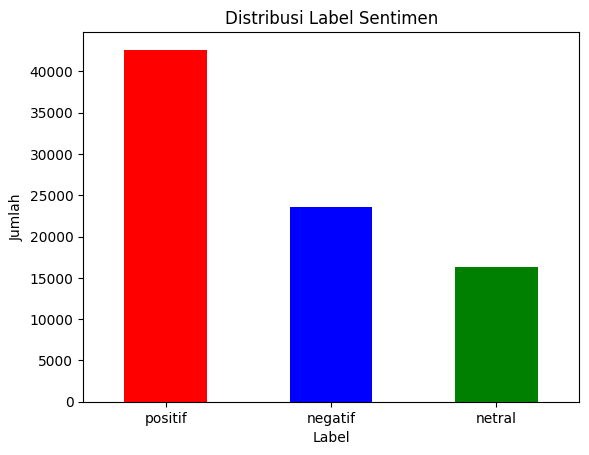

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# pengecekan distribusi label
df['label'].value_counts().plot(kind='bar', color=['red', 'blue', 'green'])
plt.title("Distribusi Label Sentimen")
plt.xlabel("Label")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

Ada masalah distribusi yang tidak seimbang

|Teknik	                        |Kelebihan	                    |Kekurangan                     |
|-------------------------------|-------------------------------|-------------------------------|
|Undersampling positif	        |Cepat, sederhana	            |Buang data berharga            |
|Oversampling netral (SMOTE)	|Tidak buang data	            |Data sintetis bisa noise       |
|Class Weighting	            |Tidak ubah data sama sekali	|Hanya ubah bobot loss function |

masuk akal memakai class weighting


In [139]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y)
print("Kelas yang ada:", classes)

weight_class = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y
)

class_weight_dict = dict(zip(classes, weight_class))
print("Class weights:", class_weight_dict)

Kelas yang ada: [0 1 2]
Class weights: {np.int64(0): np.float64(1.168401376439101), np.int64(1): np.float64(1.6822435622973881), np.int64(2): np.float64(0.645292226836536)}


Nanti dipakai saat training LSTM:  
model.fit(X_train, y_train, class_weight=class_weight_dict, ...)

Teks Mentah  
    ↓  Cleaning          (masih string)  
    ↓  Case Folding       (masih string)  
    ↓  Normalisasi slang  (pakai .split() internal, output string)  
    ↓  Stopword Removal   (masih string)  
    ↓  [Stemming]         (opsional, masih string)  
    ↓  Teks Bersih ✅     (string siap disimpan ke CSV)  
  
── Setelah semua data bersih ──  
    ↓  Tokenisasi Keras   (teks → urutan angka untuk input LSTM)  
    ↓  Padding            (samakan panjang semua urutan)  
    ↓  Masuk ke model LSTM

In [140]:
df.head()

,query,text_clean,label,label_encoded
0,korban menjadi tersangka,jelas penegak hukum polisi jaksa hakim pengaca...,positif,2
1,korban menjadi tersangka,parah nya hukum indonesia,negatif,0
2,korban menjadi tersangka,hukum penegak hukum memang bajingan negeri,positif,2
3,korban menjadi tersangka,parah memang penegak hukum negeri,positif,2
4,korban menjadi tersangka,rakyat indonesia geram sama polisi,positif,2


In [141]:
# membuat tokenization sequence
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# membuat tokenizer keras
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text_clean'])

# konversi teks ke urutan angka 
sequences = tokenizer.texts_to_sequences(df['text_clean'])

print("Contoh sebelum:", df['text_clean'][0][:50])
print("Contoh sesudah:", sequences[0][:10])
print("Ukuran vocab:", len(tokenizer.word_index)+1)

Contoh sebelum: jelas penegak hukum polisi jaksa hakim pengacara t
Contoh sesudah: [150, 231, 19, 4, 753, 704, 1151, 2696, 170, 108]
Ukuran vocab: 53872


In [74]:
# menentukan max length untuk padding
max_length = max(len(seq) for seq in sequences)
print("Panjang maksimal:", max_length)

# padding sequence agar memiliki panjang yang sama
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
print("Contoh padded:", padded_sequences[0][:100])
print("Shape padded:", padded_sequences.shape)

Panjang maksimal: 1054
Contoh padded: [ 150  231   19    4  753  704 1151 2696  170  108  140   69    1  262
 2156 8612  434  435 2765   19    1 3649  435  434 2765   19 6140  305
 3133 9605 3133   31 3317  118 3537 4741  310    1 1431    6  108 2990
  434  144  140   20   54  193    1 1069 2990 3538  150 1203   31  627
 7114    1  919  171  591    1  434 2238  531  435    1   51 5189  704
    1  753 6141    4    1  140  786 1151 6586  170  144  140 3650  282
  565 7794 3229   55  300    9  102   31  643  155   55   20   31 3053
 1807  155]
Shape padded: (82509, 1054)


## #3 Splitting Data
melakukan splitting data sesuai case

In [147]:
from sklearn.model_selection import train_test_split

X = padded_sequences
y = df['label_encoded'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,       # 80/20
    random_state=42,
    stratify=y           # pastikan distribusi label seimbang di train & test
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,       # 50/50 dari sisa 20% → 10% test, 10% val
    random_state=42,
    stratify=y_temp      # pastikan distribusi label seimbang di test & val
)

print(f"\nData training : {X_train.shape}")
print(f"Data validation: {X_val.shape}")
print(f"Data testing  : {X_test.shape}")


Data training : (66007, 1054)
Data validation: (8251, 1054)
Data testing  : (8251, 1054)


## #4 Modeling (Case 1 LSTM)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ── Parameter ──
VOCAB_SIZE     = len(tokenizer.word_index) + 1   # sesuai num_words saat Tokenizer
EMBEDDING_DIM  = 128
LSTM_UNITS     = 128
NUM_CLASSES    = 3       # positif, negatif, netral
MAX_LEN        = X_train.shape[1]  # panjang sequence setelah padding

# ── Bangun Model ──
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE, 
        output_dim=EMBEDDING_DIM, 
        input_length=MAX_LEN
    ),
    SpatialDropout1D(0.2),
    LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')  # 3 kelas
])

model.summary()

c:\Users\andre\.conda\envs\ta-skripsi\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [149]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # karena label masih integer
    metrics=['accuracy']
)

In [151]:
# ── Class Weight (atasi imbalance) ──
classes = np.unique(y_train)
class_weights = compute_class_weight(
    'balanced', 
    classes=classes, 
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

# ── Callbacks ──
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,          # berhenti jika 3 epoch tidak ada peningkatan
    restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    'best_model_lstm.h5',
    monitor='val_accuracy',
    save_best_only=True
)

# ── Training ──
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=512,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Class weights: {np.int64(0): np.float64(1.1684102455171437), np.int64(1): np.float64(1.6822641894130541), np.int64(2): np.float64(0.6452864865921734)}
Epoch 1/20
 62/129 ━━━━━━━━━━━━━━━━━━━━ 8:43 8s/step - accuracy: 0.3334 - loss: 1.1001

KeyboardInterrupt: 

### Evaluasi Model


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi
y_pred = np.argmax(model.predict(X_test), axis=1)

# Akurasi training dan testing
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc   = model.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Testing Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")

# Laporan lengkap per kelas
label_names = ['negatif', 'netral', 'positif']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_names))

In [ ]:
def prediksi_sentimen(teks_baru):
    # Preprocessing
    teks = full_preprocess(teks_baru)
    teks = ' '.join(teks) if isinstance(teks, list) else teks
    
    # Tokenisasi & padding
    seq = tokenizer.texts_to_sequences([teks])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    
    # Prediksi
    prob = model.predict(pad)[0]
    label_idx = np.argmax(prob)
    label_names = ['negatif', 'netral', 'positif']
    
    print(f"Teks    : {teks_baru}")
    print(f"Label   : {label_names[label_idx]}")
    print(f"Prob    : negatif={prob[0]:.2f}, netral={prob[1]:.2f}, positif={prob[2]:.2f}")

# Test
prediksi_sentimen("Polisi ini benar-benar tidak bertanggung jawab!")
prediksi_sentimen("Semoga kasus ini cepat diselesaikan dengan adil")